# **Predicting Heat-Related Illness Risk**

*In heat-prone US regions using Weather and Socio-Economic Indicators*

# Topic Overview

## Justification, Relevance, Usefulness

Heat-related illness (HRI) is one of the most preventable yet consistently underestimated causes of emergency department (ED) visits in the United States, with rates rising as climate change intensifies the frequency and severity of extreme heat events across the South and Southwest. Despite the growing public health burden, predictive tools that combine environmental and socioeconomic data remain limited, particularly at the regional level where resource allocation decisions are actually made.

This project addresses that gap by developing a machine learning pipeline to predict weekly HRI rates using real-world data from four authoritative sources — CDC, NOAA, ACS, and HUD — covering 21 states across Regions 4 through 9 from 2018 to 2024. The inclusion of both weather variables (maximum and minimum temperature) and socioeconomic indicators (poverty rate, unemployment, median household income, and unsheltered homelessness) reflects the reality that heat vulnerability is not uniform — lower-income and houseless populations face disproportionately higher risk due to lack of access to air conditioning, healthcare, and cooling infrastructure.

The usefulness of this project is both analytical and applied. From a modeling perspective, it demonstrates how synthetic training data calibrated to real-world distributions can support robust model development when real data volume is limited. From a public health perspective, a model that accurately predicts weekly HRI spikes — particularly during extreme heat events — can inform hospital preparedness, cooling center deployment, and early warning systems. The finding that temperature is the dominant driver, with socioeconomic factors providing meaningful but secondary signal, also contributes actionable insight into where intervention efforts should be prioritized.

## Literature Survey

Research consistently identifies ambient temperature as the strongest predictor of heat-related illness, with nonlinear effects becoming especially pronounced at extreme temperatures. Anderson and Bell (2011) demonstrated in a multi-city analysis that the relationship between heat and mortality follows a J-shaped curve, with risk accelerating sharply above local threshold temperatures — a pattern this project's polynomial temperature term was designed to capture. Similarly, Bobb et al. (2014) found that heat wave characteristics, including duration and intensity, significantly modify HRI risk beyond what daily maximum temperature alone can explain, motivating the inclusion of both maximum and minimum temperature as separate predictors.

The role of socioeconomic vulnerability in modifying heat risk is well-established. Reid et al. (2009) showed that poverty rate, housing quality, and air conditioning access were significant predictors of heat-related mortality at the census tract level, supporting this project's inclusion of poverty rate and median household income as features. Fuhrmann et al. (2016) extended this finding by demonstrating that unsheltered homeless populations face disproportionate heat exposure and have substantially elevated HRI risk — providing direct justification for incorporating HUD homelessness data as a feature in the modeling pipeline.

On the methodological side, the use of CDC National Syndromic Surveillance Program (NSSP) data for weekly ED-based HRI counts aligns with approaches taken by Hess et al. (2014), who validated syndromic surveillance as a reliable early-detection tool for heat-related illness during summer heat events. The decision to train on synthetic data and test on real-world holdout data reflects emerging best practices in public health modeling under data scarcity, as discussed by Gonzales et al. (2023), who demonstrated that synthetic datasets preserving the covariance structure of real clinical data can produce models with comparable generalizability. Finally, the use of SHAP values to interpret feature contributions follows Lundberg and Lee (2017), whose unified framework for model explainability has become standard practice in health informatics, enabling transparent communication of how weather and socioeconomic inputs drive model predictions.

## Domain Understanding Reflection

Heat-related illness (HRI) is an important public health issue that can increase significantly during extreme heat events, placing pressure on hospitals and emergency response systems. Predicting HRI trends can help support preparedness efforts, resource allocation, and early intervention strategies in heat-prone regions.

---

This project explored whether weekly HRI rates could be predicted using both weather and socioeconomic indicators. Temperature was expected to play a major role in prediction, while socioeconomic variables such as income, unemployment, poverty, population, and homelessness were included to capture differences in regional vulnerability and access to resources.

---

A major domain insight from this project is that HRI behavior is highly variable and nonlinear. Extreme heat events can produce sudden spikes in illness counts, making prediction challenging. The analysis showed that temperature-related variables were consistently the strongest predictors of HRI, especially after incorporating nonlinear feature engineering such as polynomial temperature terms and interaction effects. Socioeconomic variables contributed additional contextual information but had smaller overall impact compared to weather variables.

---

Overall, the project demonstrated that combining environmental and socioeconomic data can provide meaningful predictive insight into heat-related illness patterns, while also highlighting the complexity and variability inherent in real-world public health data.

# Importing Necessary Packages

In [1]:
# Libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import os

# Linear Regression model
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker


## Linear Regression Assumption Checks
# Homoscedasticity
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
# Independence of Errors
from statsmodels.stats.stattools import durbin_watson
# Variance
from statsmodels.stats.outliers_influence import variance_inflation_factor

# For testing all posibile combinations
from itertools import combinations

## For SHAP Analysis
import shap
# initialize JS for visualization
shap.initjs()

# Decision Tree
from __future__ import annotations

import json
from pathlib import Path

import joblib
from sklearn.tree import DecisionTreeRegressor
from IPython.display import display

# XGBoost
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from itertools import product as iprod

In [1]:
# ============================================================
# Libraries
# ============================================================

from __future__ import annotations

# Core libraries
import os
import json
from pathlib import Path
from itertools import combinations
from itertools import product as iprod

# Data handling
import pandas as pd
import numpy as np

# Statistical tests
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Model evaluation and validation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Model saving / loading
import joblib

# Notebook display
from IPython.display import display

# SHAP analysis
import shap
shap.initjs()

# **Data**

##- Data Source Understanding

In order to answer our predictive question, we built our modeling dataset by combining the following real-world data sources:

1. ***CDC*** - Health Burden Tracker
2. ***NOAA*** - Weather API
3. ***ACS*** - US Demographic Census
4. ***HUD*** - Homelessness Tracker

Our target variable, heat-related illness or HRI, came from the CDC, which provided weekly counts of Emergency Department visits for HRI at the regional level. They divided the US and its territories into 10 regions. After doing research, we narrowed down the states that are impacted by heat-waves the most, and narrowed the 10 regions down to 4. This totaled to 21 states, 1 US territory, all within the South/Southwest Region. We observed the years 2018-2024, in order to get an accurate merge across all 4 data sources.

We then incorporated weather data from NOAA, which originally came in daily station-level observations. Since our HRI data was weekly, we aggregated the weather data to the weekly regional level to ensure consistency across datasets.

In addition, we included socioeconomic variables from the American Community Survey, such as income, unemployment, poverty rates, and population count, as well as homelessness data from HUD. These datasets were at a yearly level, so we merged them into our weekly dataset by aligning on region and year.

After processing, cleaning, and merging all sources, our final dataset consisted of approximately 1,460 rows and 9 features, including both weather and socioeconomic variables.

To prepare for modeling, we then generated a synthetic training dataset based on this final merged dataset. The purpose of this was to preserve the original distributions and relationships between variables while allowing us to train more robust models. The synthetic dataset contained 2,000 rows and maintained the same feature structure.

Overall, this pipeline ensured that our data was aligned at the same level of granularity, cleaned, and structured appropriately for predictive modeling.

---

##- Descriptive Statistics

- **HRI Count** (Target Variable)
  - **Range**: 0 to 1633
  - **Mean**:
    - **Training Data**: 129
    - **Testing Data**: 122
  - **Standard Deviation**:
    - **Training Data**: 202
    - **Testing Data**: 190

The descriptive statistics show that weekly HRI ED-visit counts vary substantially, ranging from 0 to 1,633 cases. Although the average weekly HRI count is relatively moderate (129 in the training data and 122 in the testing data), the large standard deviations indicate significant variability and the presence of extreme spike periods during severe heat events. The similarity between the training and testing distributions also suggests that the synthetic training data reasonably preserves the overall behavior and scale of the real-world testing dataset.

Importing Data Files

In [2]:
# Load training dataset (synthetic data)
train_df = pd.read_csv('synthetic_hri_dataset_fixed.csv')

# Load testing dataset (real-world dataset)
test_df = pd.read_csv('final_hri_modeling_dataset.csv')

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   max_temp_celsius        2000 non-null   float64
 1   min_temp_celsius        2000 non-null   float64
 2   feat_poverty_rate       2000 non-null   float64
 3   feat_unemployment_rate  2000 non-null   float64
 4   feat_median_hh_income   2000 non-null   float64
 5   feat_total_population   2000 non-null   int64  
 6   overall_homeless        2000 non-null   int64  
 7   unsheltered_homeless    2000 non-null   int64  
 8   hri_value               2000 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 140.8 KB


In [4]:
train_df.describe()

,max_temp_celsius,min_temp_celsius,feat_poverty_rate,feat_unemployment_rate,feat_median_hh_income,feat_total_population,overall_homeless,unsheltered_homeless,hri_value
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.000000,2000.000000
mean,25.907700,3.185000,0.128790,0.063250,78938.982500,5.100015e+07,75736.073500,40638.356500,128.806000
std,8.935759,9.756965,0.008257,0.001905,8257.888494,2.413885e+05,67123.424836,48396.038045,201.689459
min,-4.500000,-26.000000,0.120456,0.059930,65780.750000,5.044032e+07,11198.000000,1737.000000,0.000000
25%,19.800000,-3.400000,0.122209,0.062331,71354.250000,5.097044e+07,24118.500000,7272.000000,9.000000
50%,26.000000,3.200000,0.127143,0.063729,82736.500000,5.108379e+07,49612.000000,17912.000000,29.000000
75%,31.925000,10.100000,0.134875,0.064025,86771.000000,5.109760e+07,79024.000000,39158.000000,167.000000
max,43.300000,28.900000,0.143754,0.066438,89433.750000,5.129606e+07,224813.000000,141325.000000,1633.000000


In [5]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hri_value               1460 non-null   int64  
 1   max_temp_celsius        1460 non-null   float64
 2   min_temp_celsius        1460 non-null   float64
 3   feat_poverty_rate       1460 non-null   float64
 4   feat_unemployment_rate  1460 non-null   float64
 5   feat_median_hh_income   1460 non-null   float64
 6   feat_total_population   1460 non-null   int64  
 7   overall_homeless        1460 non-null   int64  
 8   unsheltered_homeless    1460 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 102.8 KB


In [6]:
test_df.describe()

,hri_value,max_temp_celsius,min_temp_celsius,feat_poverty_rate,feat_unemployment_rate,feat_median_hh_income,feat_total_population,overall_homeless,unsheltered_homeless
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1.460000e+03,1460.000000,1460.000000
mean,121.889041,25.644932,2.989726,0.127539,0.062895,77294.450685,5.095233e+07,73903.760959,39366.358904
std,190.048185,9.294509,10.800250,0.008079,0.001952,8498.602602,2.612014e+05,66154.934133,47474.305223
min,0.000000,-5.500000,-26.000000,0.120456,0.059930,65780.750000,5.044032e+07,11198.000000,1737.000000
25%,9.000000,20.075000,-5.250000,0.120614,0.061154,68955.000000,5.072827e+07,24118.500000,7272.000000
50%,29.000000,27.200000,1.700000,0.123823,0.062662,75925.250000,5.104729e+07,46974.500000,18026.500000
75%,166.000000,32.800000,12.200000,0.134875,0.064025,86771.000000,5.109760e+07,76099.000000,35267.750000
max,1633.000000,43.300000,24.400000,0.143754,0.066438,89433.750000,5.129606e+07,224813.000000,141325.000000


# Splitting Testing & Training Data

In [7]:
# Define target variable (what we are predicting)
target = "hri_value"

In [8]:
# Define feature variables (predictors)
features = [
    "max_temp_celsius",
    "min_temp_celsius",
    "feat_poverty_rate",
    "feat_unemployment_rate",
    "feat_median_hh_income",
    "feat_total_population",
    "overall_homeless",
    "unsheltered_homeless"
]

In [9]:
# Split into X (features) and y (target)

# Training data
X_train = train_df[features]
y_train = train_df[target]

# Testing data
X_test = test_df[features]
y_test = test_df[target]

# Performance Criteria Determination

To evalute the model performance for predicting weekly HRI rates, we focused on the following 3 performance criterias as our primary metrics:

    1. RMSE
    2. MAE
    3. R^2

**RMSE** was chosen as our primary evaluation metric, becuase it penalizes larger predicition errors more heavily due to the squaring of residuals, which is especially important in te conext of predicitiing heat-related illness, where:
  - HRI values can vary widely (low counts to extreme spikes during heatwaves)
  - Large underpredictions during extreme heat events could lead to serious real-world consequences, such as underprepared hospitals, or insufficient public health response
RMSE ensures that the model prioritizes true values during high risk, extreme HRI periods.

**MAE** was included becuase it provides a more interpretable measure of average prediciton error. MAE represents the average absolute difference between predicted and actual HRI values. Unlike RMSE, MAE treats all errors equally and is less sensitive to extreme outliers. This makes MAE usefule in understanding:
  - On average, how far off are the model's predicitons?
  - Whether the model performs consistently across typical (non-extreme) weeks
MAE compliments RMSE by providing a more stable and easily interpretable basline error measure

**R^2** was used to measure how well the model explained the variablity in HRI values, which is important becuase:
  - It helps assess how much of HRI behavior can be captured using weather and socioeconomic factors.
  - It provides context for model performance beyond raw error values

So, we used RMSE to prioritize extreme predicition accuracy, MAE for interpretable average error, and R^2 to measure how well the model explains HRI variability.

# Model Choices
In order to answer our predicitive question, we selected three models that differed in levels of complexity and assumptions, in order to provide a comprehensive comparison. Since our target variable, 'hri_value', is a continuous variable, we chose only regression algorithms.
We attempted the following three algrotihms and compared their performance metrics to identify the best model to answer our predictive question:
1. **Decision Tree** for how it captures nonlinear relationships
2. **XGBoost** for its capability to capture complex patterns and maximize predicitve performance
3. **Linear Regression** for its simplicity and interpretability


---



Our Best Model was the **Linear Regression** Model.

# 1. Decision Tree ~ Shahzeb Ather

## Objective

Train `DecisionTreeRegressor` on **synthetic** data only; evaluate on **real** holdout for `hri_value`.

## Pipeline (what each code block does)

| # | Section |
|---|---------|
| 1 | Imports + paths |
| 2 | Load `train_df` / `real_df` |
| 3 | **PYTHON TUNING SECTION** — grid `max_depth` × `min_samples_leaf` (8 features), each `.fit` |
| 4 | **PYTHON FEATURE DROPS** — leave-one-out + progressive exclusions |
| 5 | Final `EXCLUDE_FEATURES` + build `X_train`/`X_test` (4 columns) |
| 6 | Final `model.fit` + metrics + `joblib` save |


In [10]:

TARGET_COL = "hri_value"
BASE_FEATURES = [
    "max_temp_celsius",
    "min_temp_celsius",
    "feat_poverty_rate",
    "feat_unemployment_rate",
    "feat_median_hh_income",
    "feat_total_population",
    "overall_homeless",
    "unsheltered_homeless",
]


In [11]:
train_df = train_df
real_df = test_df
for name, df in [("synthetic", train_df), ("real", real_df)]:
    miss = [c for c in BASE_FEATURES + [TARGET_COL] if c not in df.columns]
    if miss:
        raise ValueError(f"{name} missing: {miss}")
print("train_df:", train_df.shape, "real_df:", real_df.shape)


train_df: (2000, 9) real_df: (1460, 9)


## Hyperparameter grid (8 features)

Nested `for` loops: each iteration builds a new `DecisionTreeRegressor`, calls **`.fit()`** on synthetic rows with **all 8** `BASE_FEATURES`, scores **synthetic train RMSE** and **real holdout RMSE**.

In [12]:
def _rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def eval_decision_tree(X_tr, y_tr, X_te, y_te, max_depth, min_samples_leaf, min_samples_split=2, rs=42):
    m = DecisionTreeRegressor(
        random_state=rs,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
    )
    m.fit(X_tr, y_tr)
    p_tr = m.predict(X_tr)
    p_te = m.predict(X_te)
    return {
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "n_leaves": int(m.get_n_leaves()),
        "tree_depth": int(m.get_depth()),
        "train_rmse": _rmse(y_tr.values, p_tr),
        "real_rmse": _rmse(y_te.values, p_te),
        "real_mae": float(mean_absolute_error(y_te, p_te)),
        "real_r2": float(r2_score(y_te, p_te)),
    }

X_train_full = train_df[BASE_FEATURES].copy()
y_train_full = train_df[TARGET_COL].astype(float)
X_test_full = real_df[BASE_FEATURES].copy()
y_test_full = real_df[TARGET_COL].astype(float)
ok_tr = X_train_full.notna().all(axis=1) & y_train_full.notna()
ok_te = X_test_full.notna().all(axis=1) & y_test_full.notna()
X_train_full, y_train_full = X_train_full.loc[ok_tr], y_train_full.loc[ok_tr]
X_test_full, y_test_full = X_test_full.loc[ok_te], y_test_full.loc[ok_te]

depth_grid = [5, 6, 8, 9, 10]
leaf_grid = [8, 9, 10, 11, 12]
hp_rows = []
for d in depth_grid:
    for leaf in leaf_grid:
        hp_rows.append(eval_decision_tree(X_train_full, y_train_full, X_test_full, y_test_full, d, leaf))
hp_df = pd.DataFrame(hp_rows).sort_values("real_rmse").reset_index(drop=True)
print("Hyperparameter grid fits:", len(hp_df))
display(hp_df.round(4))
print("Best row (lowest real RMSE):")
display(hp_df.head(1).T.round(4))


Hyperparameter grid fits: 25


,max_depth,min_samples_leaf,n_leaves,tree_depth,train_rmse,real_rmse,real_mae,real_r2
0,6,10,42,6,155.3817,163.6239,105.1342,0.2582
1,6,11,42,6,155.4444,163.6239,105.1342,0.2582
2,5,9,28,5,158.1601,163.8491,104.2933,0.2562
3,5,11,28,5,158.3113,163.8563,104.2991,0.2561
4,5,10,28,5,158.3113,163.8563,104.2991,0.2561
5,5,8,29,5,158.0725,163.9214,104.3481,0.2555
6,6,8,43,6,154.9981,163.9486,104.9672,0.2553
7,5,12,28,5,158.3928,164.0211,104.4251,0.2546
8,6,9,42,6,155.0894,164.0322,105.3353,0.2545
9,6,12,42,6,155.5320,164.5929,105.6583,0.2494


Best row (lowest real RMSE):


,0
max_depth,6.0000
min_samples_leaf,10.0000
n_leaves,42.0000
tree_depth,6.0000
train_rmse,155.3817
real_rmse,163.6239
real_mae,105.1342
real_r2,0.2582


## Feature Dropping

Fixed hyperparameters for this block: **`max_depth=5`**, **`min_samples_leaf=9`**, **`min_samples_split=2`**, **`random_state=42`** (same as frozen model).
1) Leave-one-out: drop each feature once. 2) Progressive exclusion chain to the final 4-feature set.


In [13]:
FIX_DEPTH, FIX_LEAF, FIX_SPLIT, FIX_RS = 5, 9, 2, 42

single_rows = []
for drop in BASE_FEATURES:
    feats = [c for c in BASE_FEATURES if c != drop]
    X_tr = train_df[feats].copy()
    y_tr = train_df[TARGET_COL].astype(float)
    X_te = real_df[feats].copy()
    y_te = real_df[TARGET_COL].astype(float)
    m_tr = X_tr.notna().all(axis=1) & y_tr.notna()
    m_te = X_te.notna().all(axis=1) & y_te.notna()
    X_tr, y_tr = X_tr.loc[m_tr], y_tr.loc[m_tr]
    X_te, y_te = X_te.loc[m_te], y_te.loc[m_te]
    r = eval_decision_tree(X_tr, y_tr, X_te, y_te, FIX_DEPTH, FIX_LEAF, FIX_SPLIT, FIX_RS)
    r["dropped_one"] = drop
    single_rows.append(r)
single_df = pd.DataFrame(single_rows).sort_values("real_rmse")
print("=== Leave-one-out feature drops ===")
display(single_df[["dropped_one", "train_rmse", "real_rmse", "real_mae", "n_leaves"]].round(4))

chains = [
    [],
    ["max_temp_celsius"],
    ["max_temp_celsius", "feat_unemployment_rate"],
    ["max_temp_celsius", "feat_unemployment_rate", "feat_poverty_rate"],
    ["max_temp_celsius", "feat_unemployment_rate", "feat_poverty_rate", "overall_homeless"],
]
chain_rows = []
for exc in chains:
    exc_set = set(exc)
    feats = [c for c in BASE_FEATURES if c not in exc_set]
    X_tr = train_df[feats].copy()
    y_tr = train_df[TARGET_COL].astype(float)
    X_te = real_df[feats].copy()
    y_te = real_df[TARGET_COL].astype(float)
    m_tr = X_tr.notna().all(axis=1) & y_tr.notna()
    m_te = X_te.notna().all(axis=1) & y_te.notna()
    X_tr, y_tr = X_tr.loc[m_tr], y_tr.loc[m_tr]
    X_te, y_te = X_te.loc[m_te], y_te.loc[m_te]
    r = eval_decision_tree(X_tr, y_tr, X_te, y_te, FIX_DEPTH, FIX_LEAF, FIX_SPLIT, FIX_RS)
    r["excluded"] = ",".join(exc) if exc else "(none)"
    r["n_features"] = len(feats)
    chain_rows.append(r)
chain_df = pd.DataFrame(chain_rows)
print("=== Progressive exclusions ===")
display(chain_df[["excluded", "n_features", "train_rmse", "real_rmse", "real_mae", "n_leaves"]].round(4))


=== Leave-one-out feature drops ===


,dropped_one,train_rmse,real_rmse,real_mae,n_leaves
0,max_temp_celsius,161.7546,163.2467,97.1107,32
2,feat_poverty_rate,158.1601,163.5767,103.9479,28
3,feat_unemployment_rate,158.1601,163.5767,103.9479,28
1,min_temp_celsius,160.3848,164.9785,103.2882,28
4,feat_median_hh_income,158.1601,165.2795,105.6484,28
5,feat_total_population,158.1601,165.2795,105.6484,28
7,unsheltered_homeless,158.1601,165.2795,105.6484,28
6,overall_homeless,158.5819,168.3951,107.2074,28


=== Progressive exclusions ===


,excluded,n_features,train_rmse,real_rmse,real_mae,n_leaves
0,(none),8,158.1601,163.8491,104.2933,28
1,max_temp_celsius,7,161.7546,163.2467,97.1107,32
2,"max_temp_celsius,feat_unemployment_rate",6,161.7546,162.9561,96.2323,32
3,"max_temp_celsius,feat_unemployment_rate,feat_p...",5,161.7546,157.0329,93.3612,32
4,"max_temp_celsius,feat_unemployment_rate,feat_p...",4,162.2130,152.9362,91.7907,32


## Final frozen model — 4 features + hyperparameters



In [14]:
EXCLUDE_FEATURES = [
    "max_temp_celsius",
    "feat_unemployment_rate",
    "feat_poverty_rate",
    "overall_homeless",
]
feature_cols = [c for c in BASE_FEATURES if c not in EXCLUDE_FEATURES]
RANDOM_STATE = 42
MAX_DEPTH = 5
MIN_SAMPLES_LEAF = 9
MIN_SAMPLES_SPLIT = 2
print("Final feature_cols:", feature_cols)


Final feature_cols: ['min_temp_celsius', 'feat_median_hh_income', 'feat_total_population', 'unsheltered_homeless']


### Build final X, y — then final `.fit()`


In [15]:
X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET_COL].astype(float)
X_test = real_df[feature_cols].copy()
y_test = real_df[TARGET_COL].astype(float)
train_ok = X_train.notna().all(axis=1) & y_train.notna()
test_ok = X_test.notna().all(axis=1) & y_test.notna()
X_train, y_train = X_train.loc[train_ok], y_train.loc[train_ok]
X_test, y_test = X_test.loc[test_ok], y_test.loc[test_ok]
print(len(X_train), "train rows |", len(X_test), "test rows")


2000 train rows | 1460 test rows


### Final `DecisionTreeRegressor.fit` (submission model)

In [16]:
model = DecisionTreeRegressor(
    random_state=RANDOM_STATE,
    max_depth=MAX_DEPTH,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    min_samples_split=MIN_SAMPLES_SPLIT,
)
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

def rmse(a, b) -> float:
    return float(np.sqrt(mean_squared_error(a, b)))

print("=== FINAL MODEL TRAINING COMPLETE ===")
print("depth", model.get_depth(), "leaves", model.get_n_leaves(), "rows", len(X_train))


=== FINAL MODEL TRAINING COMPLETE ===
depth 5 leaves 32 rows 2000


### Metrics + importances


In [17]:
metrics_train = {
    "mae": mean_absolute_error(y_train, y_pred_train),
    "rmse": rmse(y_train.values, y_pred_train),
    "r2": r2_score(y_train, y_pred_train),
}
metrics_test = {
    "mae": mean_absolute_error(y_test, y_pred_test),
    "rmse": rmse(y_test.values, y_pred_test),
    "r2": r2_score(y_test, y_pred_test),
}
display(pd.DataFrame([metrics_train, metrics_test], index=["synthetic_fit", "real_holdout"]).round(4))
display(pd.Series(model.feature_importances_, index=feature_cols, name="importance").sort_values(ascending=False).to_frame().round(4))


,mae,rmse,r2
synthetic_fit,100.4198,162.2130,0.3528
real_holdout,91.7907,152.9362,0.3520


,importance
min_temp_celsius,0.8979
unsheltered_homeless,0.0575
feat_median_hh_income,0.0282
feat_total_population,0.0164


# 2. XGBoost ~ Jasmine Cheng

In [18]:
RANDOM_STATE = 42
os.makedirs('models', exist_ok=True)

def evaluate(model, X_te, y_te, label=''):
    preds = np.clip(model.predict(X_te), 0, None)
    mae   = mean_absolute_error(y_te, preds)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    r2    = r2_score(y_te, preds)
    tag   = f'[{label}] ' if label else ''
    print(f'  {tag}MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')
    return mae, rmse, r2, preds

def grid_search(X_tr, y_tr, param_grid, kf):
    combos = list(iprod(*param_grid.values()))
    keys   = list(param_grid.keys())
    best_rmse, best_params, all_results = np.inf, {}, []
    for combo in combos:
        params = dict(zip(keys, combo))
        m = XGBRegressor(**params, objective='reg:squarederror',
                         random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
        s = cross_val_score(m, X_tr, y_tr, cv=kf,
                            scoring='neg_mean_squared_error', n_jobs=-1)
        cv_rmse = np.sqrt(-s.mean())
        all_results.append({**params, 'cv_rmse': round(cv_rmse, 4)})
        if cv_rmse < best_rmse:
            best_rmse, best_params = cv_rmse, params
    return best_params, best_rmse, pd.DataFrame(all_results).sort_values('cv_rmse')

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

PARAM_GRID = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

# Tracks all valid experiments for final comparison
EXPERIMENT_LOG = []

print('Setup complete.')

Setup complete.


## 1. Load Data

In [19]:
df_train_raw = pd.read_csv('synthetic_hri_dataset_fixed.csv')
df_test_raw  = pd.read_csv('final_hri_modeling_dataset.csv')

print(f'Training set : {df_train_raw.shape[0]} rows × {df_train_raw.shape[1]} columns')
print(f'Test set     : {df_test_raw.shape[0]} rows × {df_test_raw.shape[1]} columns')

TARGET = 'hri_value'
META   = ['regionid']

ORIGINAL_FEATURES = [c for c in df_train_raw.columns if c not in [TARGET] + META]

# Explicitly label which features serve the project objective
WEATHER_FEATURES = ['max_temp_celsius', 'min_temp_celsius']
SOCIOECONOMIC_FEATURES = ['feat_poverty_rate', 'feat_unemployment_rate',
                           'feat_median_hh_income', 'feat_total_population',
                           'overall_homeless', 'unsheltered_homeless']

print(f'\nWeather features      : {WEATHER_FEATURES}')
print(f'Socioeconomic features: {SOCIOECONOMIC_FEATURES}')
print(f'\n⚠️  Project objective requires BOTH groups to be present in the final model.')

Training set : 2000 rows × 9 columns
Test set     : 1460 rows × 9 columns

Weather features      : ['max_temp_celsius', 'min_temp_celsius']
Socioeconomic features: ['feat_poverty_rate', 'feat_unemployment_rate', 'feat_median_hh_income', 'feat_total_population', 'overall_homeless', 'unsheltered_homeless']

⚠️  Project objective requires BOTH groups to be present in the final model.


## 2. EDA

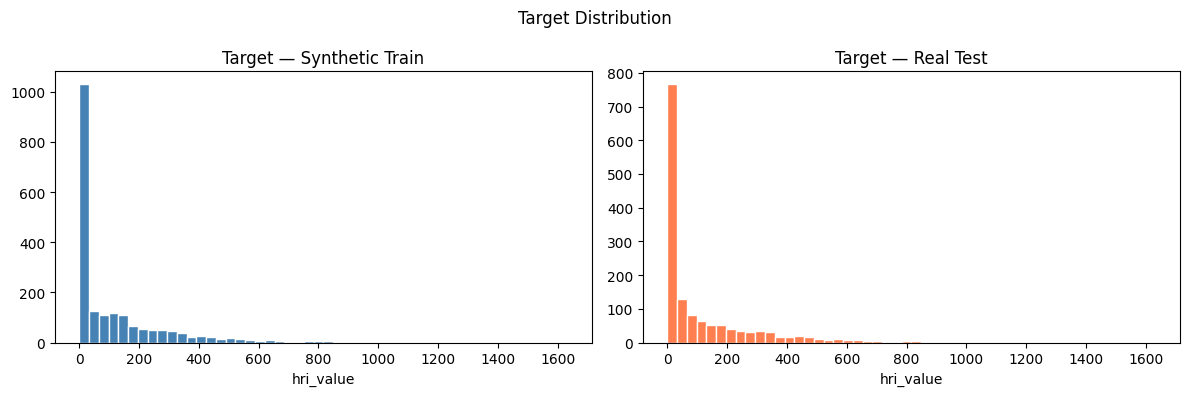

Train — mean: 128.8, std: 201.7
Test  — mean: 121.9,  std: 190.0


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_train_raw[TARGET], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Target — Synthetic Train'); axes[0].set_xlabel('hri_value')
axes[1].hist(df_test_raw[TARGET],  bins=50, color='coral',     edgecolor='white')
axes[1].set_title('Target — Real Test');     axes[1].set_xlabel('hri_value')
plt.suptitle('Target Distribution'); plt.tight_layout()
plt.savefig('plot_target_dist.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"Train — mean: {df_train_raw[TARGET].mean():.1f}, std: {df_train_raw[TARGET].std():.1f}")
print(f"Test  — mean: {df_test_raw[TARGET].mean():.1f},  std: {df_test_raw[TARGET].std():.1f}")

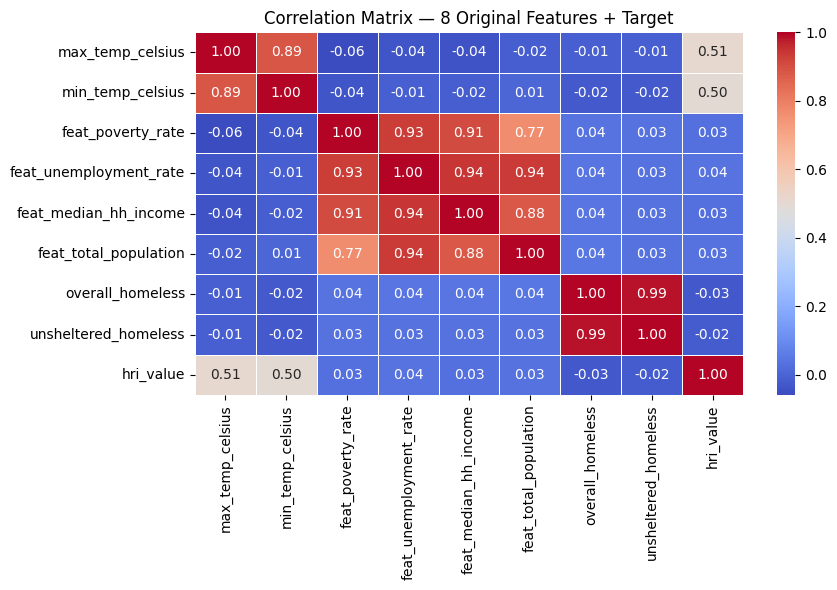

In [21]:
plt.figure(figsize=(9, 6))
corr = df_train_raw[ORIGINAL_FEATURES + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix — 8 Original Features + Target')
plt.tight_layout(); plt.savefig('plot_correlation.png', dpi=150, bbox_inches='tight'); plt.show()

## 3. E1 — Baseline: Default Params, 8 Original Features

No tuning, no engineering. Performance floor — both weather + socioeconomic features present. ✅

In [22]:
X_train_8 = df_train_raw[ORIGINAL_FEATURES]
y_train   = df_train_raw[TARGET]
X_test_8  = df_test_raw[ORIGINAL_FEATURES]
y_test    = df_test_raw[TARGET]

e1_model = XGBRegressor(objective='reg:squarederror',
                        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
e1_model.fit(X_train_8, y_train)

print('E1 — Baseline (default params, 8 features):')
e1_mae, e1_rmse, e1_r2, _ = evaluate(e1_model, X_test_8, y_test)

EXPERIMENT_LOG.append({'experiment': 'E1 Baseline (8 features)',
                        'n_features': 8, 'tuned': 'No', 'feature_eng': 'No', 'valid': '✅',
                        'MAE': round(e1_mae,4), 'RMSE': round(e1_rmse,4), 'R2': round(e1_r2,4)})

E1 — Baseline (default params, 8 features):
  MAE=115.4181  RMSE=186.3119  R2=0.0383


## 4. E2 — Grid Search Tuning, 8 Original Features

108-combination grid search (5-fold CV on synthetic train). Same 8 features — objective satisfied. ✅

In [23]:
print('Running grid search on 8 original features (108 combinations)...')
e2_best_params, e2_cv_rmse, e2_results = grid_search(X_train_8, y_train, PARAM_GRID, kf)
print(f'Best CV RMSE : {e2_cv_rmse:.4f}')
print(f'Best params  : {e2_best_params}')
print('\nTop 5 combinations:')
display(e2_results.head())

Running grid search on 8 original features (108 combinations)...
Best CV RMSE : 167.8861
Best params  : {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 0.8}

Top 5 combinations:


,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,cv_rmse
2,100,3,0.05,1.0,0.8,167.8861
1,100,3,0.05,0.8,1.0,168.1685
3,100,3,0.05,1.0,1.0,168.3841
0,100,3,0.05,0.8,0.8,168.7622
6,100,3,0.10,1.0,0.8,170.5803


In [24]:
e2_model = XGBRegressor(**e2_best_params, reg_alpha=0.1, reg_lambda=1.0,
                        objective='reg:squarederror',
                        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
e2_model.fit(X_train_8, y_train)

print('E2 — Tuned, 8 original features:')
e2_mae, e2_rmse, e2_r2, _ = evaluate(e2_model, X_test_8, y_test)

EXPERIMENT_LOG.append({'experiment': 'E2 Tuned (8 features)',
                        'n_features': 8, 'tuned': 'Yes', 'feature_eng': 'No', 'valid': '✅',
                        'MAE': round(e2_mae,4), 'RMSE': round(e2_rmse,4), 'R2': round(e2_r2,4)})

E2 — Tuned, 8 original features:
  MAE=96.0087  RMSE=154.4994  R2=0.3387


## 5. E3 — Feature Engineering: Add 4 Derived Features (8 → 12 total)

New features derived from existing ones — all socioeconomic context preserved. ✅

| New Feature | Formula | Rationale |
|---|---|---|
| `feat_temp_range` | max_temp − min_temp | Weekly temperature swing |
| `feat_heat_intensity` | max_temp × temp_range | Combined heat stress |
| `feat_unsheltered_ratio` | unsheltered / overall_homeless | Vulnerability proxy |
| `feat_homeless_density` | overall_homeless / population × 100k | Homeless per capita |

In [25]:
def add_features(df):
    df = df.copy()
    df['feat_temp_range']        = df['max_temp_celsius'] - df['min_temp_celsius']
    df['feat_heat_intensity']    = df['max_temp_celsius'] * df['feat_temp_range']
    df['feat_unsheltered_ratio'] = df['unsheltered_homeless'] / df['overall_homeless'].clip(lower=1)
    df['feat_homeless_density']  = df['overall_homeless'] / df['feat_total_population'].clip(lower=1) * 100_000
    return df

df_train_eng = add_features(df_train_raw)
df_test_eng  = add_features(df_test_raw)

ENGINEERED_FEATURES = ORIGINAL_FEATURES + [
    'feat_temp_range', 'feat_heat_intensity',
    'feat_unsheltered_ratio', 'feat_homeless_density'
]

X_train_12 = df_train_eng[ENGINEERED_FEATURES]
X_test_12  = df_test_eng[ENGINEERED_FEATURES]

print(f'Features: 8 → {len(ENGINEERED_FEATURES)}')
print(f'Added   : {ENGINEERED_FEATURES[8:]}')

Features: 8 → 12
Added   : ['feat_temp_range', 'feat_heat_intensity', 'feat_unsheltered_ratio', 'feat_homeless_density']


In [26]:
e3_model = XGBRegressor(objective='reg:squarederror',
                        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
e3_model.fit(X_train_12, y_train)

print('E3 — Default params, 12 features:')
e3_mae, e3_rmse, e3_r2, _ = evaluate(e3_model, X_test_12, y_test)

EXPERIMENT_LOG.append({'experiment': 'E3 Baseline (12 features)',
                        'n_features': 12, 'tuned': 'No', 'feature_eng': 'Yes', 'valid': '✅',
                        'MAE': round(e3_mae,4), 'RMSE': round(e3_rmse,4), 'R2': round(e3_r2,4)})

E3 — Default params, 12 features:
  MAE=117.5179  RMSE=185.5714  R2=0.0459


## 6. E4 — Grid Search Tuning on 12 Engineered Features

Same 108-combination grid, applied to the 12-feature set. ✅

In [27]:
print('Running grid search on 12 engineered features (108 combinations)...')
e4_best_params, e4_cv_rmse, e4_results = grid_search(X_train_12, y_train, PARAM_GRID, kf)
print(f'Best CV RMSE : {e4_cv_rmse:.4f}')
print(f'Best params  : {e4_best_params}')
print('\nTop 5 combinations:')
display(e4_results.head())

Running grid search on 12 engineered features (108 combinations)...
Best CV RMSE : 168.9790
Best params  : {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 0.8}

Top 5 combinations:


,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,cv_rmse
2,100,3,0.05,1.0,0.8,168.9790
3,100,3,0.05,1.0,1.0,169.2364
0,100,3,0.05,0.8,0.8,169.7163
1,100,3,0.05,0.8,1.0,170.1922
38,200,3,0.05,1.0,0.8,171.5196


In [28]:
e4_model = XGBRegressor(**e4_best_params, reg_alpha=0.1, reg_lambda=1.0,
                        objective='reg:squarederror',
                        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
e4_model.fit(X_train_12, y_train)

print('E4 — Tuned, 12 features:')
e4_mae, e4_rmse, e4_r2, _ = evaluate(e4_model, X_test_12, y_test)

EXPERIMENT_LOG.append({'experiment': 'E4 Tuned (12 features)',
                        'n_features': 12, 'tuned': 'Yes', 'feature_eng': 'Yes', 'valid': '✅',
                        'MAE': round(e4_mae,4), 'RMSE': round(e4_rmse,4), 'R2': round(e4_r2,4)})

# Gain importance — used to guide E5 feature selection
imp = e4_model.get_booster().get_score(importance_type='gain')
imp_df = pd.DataFrame(list(imp.items()), columns=['Feature','Gain']).sort_values('Gain', ascending=False)
zero_gain = [f for f in ENGINEERED_FEATURES if f not in imp]
print(f'\nZero-gain features (never used in any split): {zero_gain}')

E4 — Tuned, 12 features:
  MAE=98.1035  RMSE=155.1588  R2=0.3330

Zero-gain features (never used in any split): ['feat_median_hh_income', 'feat_total_population']


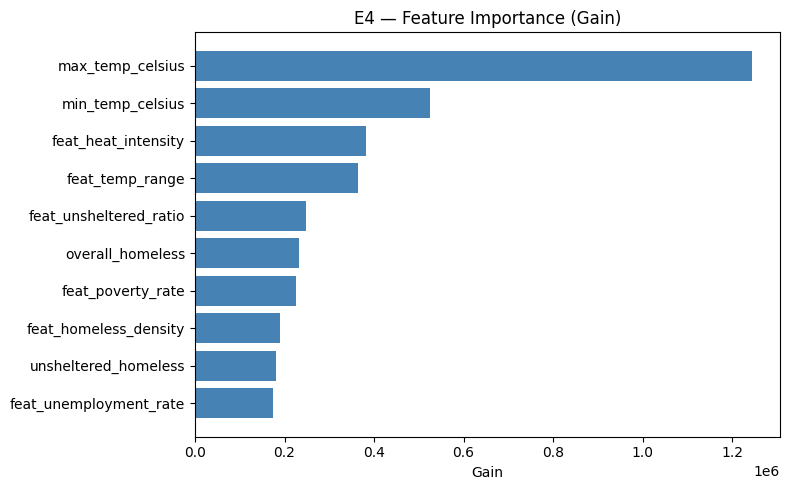

In [29]:
plt.figure(figsize=(8, 5))
plt.barh(imp_df['Feature'][::-1], imp_df['Gain'][::-1], color='steelblue')
plt.xlabel('Gain'); plt.title('E4 — Feature Importance (Gain)')
plt.tight_layout(); plt.savefig('plot_importance_e4.png', dpi=150, bbox_inches='tight'); plt.show()

## 7. E5 — Constrained Feature Selection (Objective-Aware)

We drop low-gain features **one by one from the bottom of the ranking**, with one hard constraint:

> ⚠️ **At least one weather feature AND at least one socioeconomic feature must remain.**

Any subset that violates this constraint is automatically disqualified — even if it gives a lower RMSE.

In [30]:
# Rank all 12 features by gain; zero-gain features go to the bottom
ranked = list(imp_df['Feature'])
zero_gain_feats = [f for f in ENGINEERED_FEATURES if f not in ranked]
RANKED_ALL = ranked + zero_gain_feats

print('Feature ranking (gain — high to low):')
for i, f in enumerate(RANKED_ALL, 1):
    gain    = imp.get(f, 0)
    f_type  = 'weather' if f in WEATHER_FEATURES else 'socioeconomic/derived'
    print(f'  {i:2d}. {f:<30} gain={gain:>12,.0f}  [{f_type}]')

Feature ranking (gain — high to low):
   1. max_temp_celsius               gain=   1,244,662  [weather]
   2. min_temp_celsius               gain=     525,396  [weather]
   3. feat_heat_intensity            gain=     381,166  [socioeconomic/derived]
   4. feat_temp_range                gain=     363,693  [socioeconomic/derived]
   5. feat_unsheltered_ratio         gain=     247,193  [socioeconomic/derived]
   6. overall_homeless               gain=     231,290  [socioeconomic/derived]
   7. feat_poverty_rate              gain=     224,760  [socioeconomic/derived]
   8. feat_homeless_density          gain=     189,585  [socioeconomic/derived]
   9. unsheltered_homeless           gain=     180,334  [socioeconomic/derived]
  10. feat_unemployment_rate         gain=     175,399  [socioeconomic/derived]
  11. feat_median_hh_income          gain=           0  [socioeconomic/derived]
  12. feat_total_population          gain=           0  [socioeconomic/derived]


In [31]:
ALL_SOCIOECONOMIC = SOCIOECONOMIC_FEATURES + [
    'feat_unsheltered_ratio', 'feat_homeless_density',
    'feat_poverty_rate', 'feat_unemployment_rate',
    'feat_median_hh_income', 'feat_total_population'
]
ALL_WEATHER = WEATHER_FEATURES + ['feat_temp_range', 'feat_heat_intensity']

fs_results = []

for drop_n in range(0, len(RANKED_ALL) - 1):
    feats   = RANKED_ALL[:len(RANKED_ALL) - drop_n] if drop_n > 0 else RANKED_ALL
    dropped = RANKED_ALL[len(RANKED_ALL) - drop_n:] if drop_n > 0 else []

    has_weather = any(f in ALL_WEATHER for f in feats)
    has_socio   = any(f in ALL_SOCIOECONOMIC for f in feats)
    valid = has_weather and has_socio

    m = XGBRegressor(**e4_best_params, reg_alpha=0.1, reg_lambda=1.0,
                     objective='reg:squarederror',
                     random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    cv_s    = cross_val_score(m, df_train_eng[feats], y_train, cv=kf,
                               scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_rmse = -cv_s.mean()
    m.fit(df_train_eng[feats], y_train)
    p    = np.clip(m.predict(df_test_eng[feats]), 0, None)
    rmse = np.sqrt(mean_squared_error(y_test, p))
    mae  = mean_absolute_error(y_test, p)
    r2   = r2_score(y_test, p)

    status = '✅' if valid else '❌ disqualified (drops objective)'
    fs_results.append({'n_features': len(feats), 'features_kept': feats,
                       'dropped': dropped, 'valid': valid,
                       'cv_rmse': round(cv_rmse,4), 'real_rmse': round(rmse,4),
                       'real_mae': round(mae,4), 'real_r2': round(r2,4)})
    print(f'  n={len(feats):2d} | real_rmse={rmse:.4f} | cv_rmse={cv_rmse:.4f} | {status}')

fs_df_all   = pd.DataFrame(fs_results)
fs_df_valid = fs_df_all[fs_df_all['valid']].sort_values('real_rmse').reset_index(drop=True)
print(f'\nBest VALID subset: {fs_df_valid.iloc[0]["n_features"]} features  |  real_rmse={fs_df_valid.iloc[0]["real_rmse"]}')

  n=12 | real_rmse=155.3390 | cv_rmse=168.7790 | ✅
  n=11 | real_rmse=155.4441 | cv_rmse=169.0419 | ✅
  n=10 | real_rmse=154.5567 | cv_rmse=169.0348 | ✅
  n= 9 | real_rmse=156.2750 | cv_rmse=168.6259 | ✅
  n= 8 | real_rmse=155.5550 | cv_rmse=168.6631 | ✅
  n= 7 | real_rmse=154.5510 | cv_rmse=169.3106 | ✅
  n= 6 | real_rmse=152.9357 | cv_rmse=169.4280 | ✅
  n= 5 | real_rmse=153.3564 | cv_rmse=170.4710 | ✅
  n= 4 | real_rmse=152.0449 | cv_rmse=170.8903 | ❌ disqualified (drops objective)
  n= 3 | real_rmse=150.9992 | cv_rmse=170.3621 | ❌ disqualified (drops objective)
  n= 2 | real_rmse=148.0804 | cv_rmse=168.3693 | ❌ disqualified (drops objective)

Best VALID subset: 6 features  |  real_rmse=152.9357


/tmp/ipykernel_12466/2513609165.py:24: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12466/2513609165.py:25: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('plot_feature_selection_constrained.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


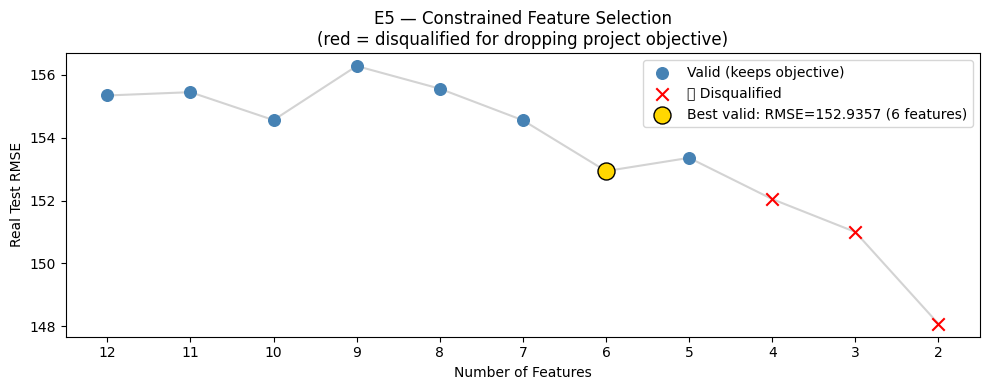

In [32]:
# Plot: RMSE vs feature count, highlight valid vs disqualified
fig, ax = plt.subplots(figsize=(10, 4))

valid_pts   = fs_df_all[fs_df_all['valid']]
invalid_pts = fs_df_all[~fs_df_all['valid']]

ax.plot(fs_df_all.sort_values('n_features')['n_features'],
        fs_df_all.sort_values('n_features')['real_rmse'],
        color='lightgrey', linewidth=1.5, zorder=1)
ax.scatter(valid_pts['n_features'],   valid_pts['real_rmse'],
           color='steelblue', s=70, zorder=3, label='Valid (keeps objective)')
ax.scatter(invalid_pts['n_features'], invalid_pts['real_rmse'],
           color='red', marker='x', s=80, zorder=3, label='❌ Disqualified')

best_valid = fs_df_valid.iloc[0]
ax.scatter(best_valid['n_features'], best_valid['real_rmse'],
           color='gold', s=150, zorder=5, edgecolors='black',
           label=f"Best valid: RMSE={best_valid['real_rmse']} ({int(best_valid['n_features'])} features)")

ax.set_xlabel('Number of Features'); ax.set_ylabel('Real Test RMSE')
ax.set_title('E5 — Constrained Feature Selection\n(red = disqualified for dropping project objective)')
ax.legend(); ax.invert_xaxis()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('plot_feature_selection_constrained.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Add best valid E5 result to experiment log
best_e5 = fs_df_valid.iloc[0]
BEST_FEATURES_E5 = best_e5['features_kept']

e5_model = XGBRegressor(**e4_best_params, reg_alpha=0.1, reg_lambda=1.0,
                        objective='reg:squarederror',
                        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
e5_model.fit(df_train_eng[BEST_FEATURES_E5], y_train)

print(f'E5 — Best valid feature subset ({len(BEST_FEATURES_E5)} features):')
for f in BEST_FEATURES_E5:
    print(f'  - {f}')
print()
e5_mae, e5_rmse, e5_r2, e5_preds = evaluate(e5_model, df_test_eng[BEST_FEATURES_E5], y_test)

EXPERIMENT_LOG.append({'experiment': 'E5 Feature Selection (valid)',
                        'n_features': len(BEST_FEATURES_E5), 'tuned': 'Yes',
                        'feature_eng': 'Yes', 'valid': '✅',
                        'MAE': round(e5_mae,4), 'RMSE': round(e5_rmse,4), 'R2': round(e5_r2,4)})

E5 — Best valid feature subset (6 features):
  - max_temp_celsius
  - min_temp_celsius
  - feat_heat_intensity
  - feat_temp_range
  - feat_unsheltered_ratio
  - overall_homeless

  MAE=96.4823  RMSE=152.9357  R2=0.3520


## 8. Why Pure Temperature Models Are Disqualified

During feature selection, dropping all socioeconomic features yields lower RMSE
(e.g. temperature-only RMSE ≈ 148) — but this violates the project objective.

We document this here for transparency, then **exclude it from the final selection**.

In [34]:
# Train temperature-only model just to document the RMSE gap
temp_only_feats = ['max_temp_celsius', 'min_temp_celsius']
m_temp = XGBRegressor(**e4_best_params, reg_alpha=0.1, reg_lambda=1.0,
                      objective='reg:squarederror',
                      random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
m_temp.fit(df_train_eng[temp_only_feats], y_train)
p_temp = np.clip(m_temp.predict(df_test_eng[temp_only_feats]), 0, None)
rmse_temp = np.sqrt(mean_squared_error(y_test, p_temp))
r2_temp   = r2_score(y_test, p_temp)

print('Temperature-only model (2 features):')
print(f'  RMSE = {rmse_temp:.4f}  R2 = {r2_temp:.4f}')
print()
print('❌ DISQUALIFIED — drops all socioeconomic features.')
print('   Cannot answer: "Does poverty/unemployment/homelessness affect HRI?"')
print('   Lower RMSE does NOT override the research objective.')

Temperature-only model (2 features):
  RMSE = 148.0804  R2 = 0.3925

❌ DISQUALIFIED — drops all socioeconomic features.
   Cannot answer: "Does poverty/unemployment/homelessness affect HRI?"
   Lower RMSE does NOT override the research objective.


## 9. Full Experiment Comparison & Best Model Selection

Only experiments that satisfy the project objective are eligible for selection.

In [35]:
log_df = pd.DataFrame(EXPERIMENT_LOG)
log_df['recommended'] = log_df['RMSE'] == log_df['RMSE'].min()

print('=== All Valid Experiments ===')
display(log_df[['experiment','n_features','tuned','feature_eng','MAE','RMSE','R2','recommended']])

best = log_df.loc[log_df['RMSE'].idxmin()]
print(f'\n✅ Recommended model: {best["experiment"]}  (RMSE={best["RMSE"]})')

=== All Valid Experiments ===


,experiment,n_features,tuned,feature_eng,MAE,RMSE,R2,recommended
0,E1 Baseline (8 features),8,No,No,115.4181,186.3119,0.0383,False
1,E2 Tuned (8 features),8,Yes,No,96.0087,154.4994,0.3387,False
2,E3 Baseline (12 features),12,No,Yes,117.5179,185.5714,0.0459,False
3,E4 Tuned (12 features),12,Yes,Yes,98.1035,155.1588,0.3330,False
4,E5 Feature Selection (valid),6,Yes,Yes,96.4823,152.9357,0.3520,True



✅ Recommended model: E5 Feature Selection (valid)  (RMSE=152.9357)


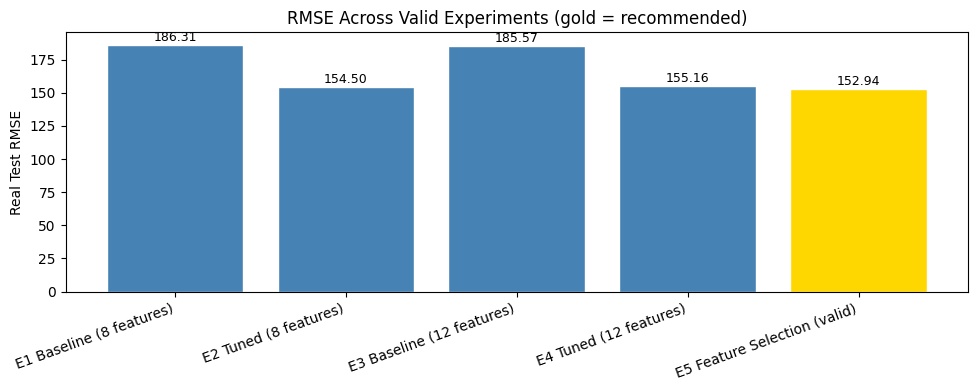

In [36]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['gold' if r else 'steelblue' for r in log_df['recommended']]
bars = ax.bar(log_df['experiment'], log_df['RMSE'], color=colors, edgecolor='white')
ax.set_ylabel('Real Test RMSE')
ax.set_title('RMSE Across Valid Experiments (gold = recommended)')
plt.xticks(rotation=20, ha='right')
for bar, val in zip(bars, log_df['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plot_experiment_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

## 10. Best Model Diagnostics

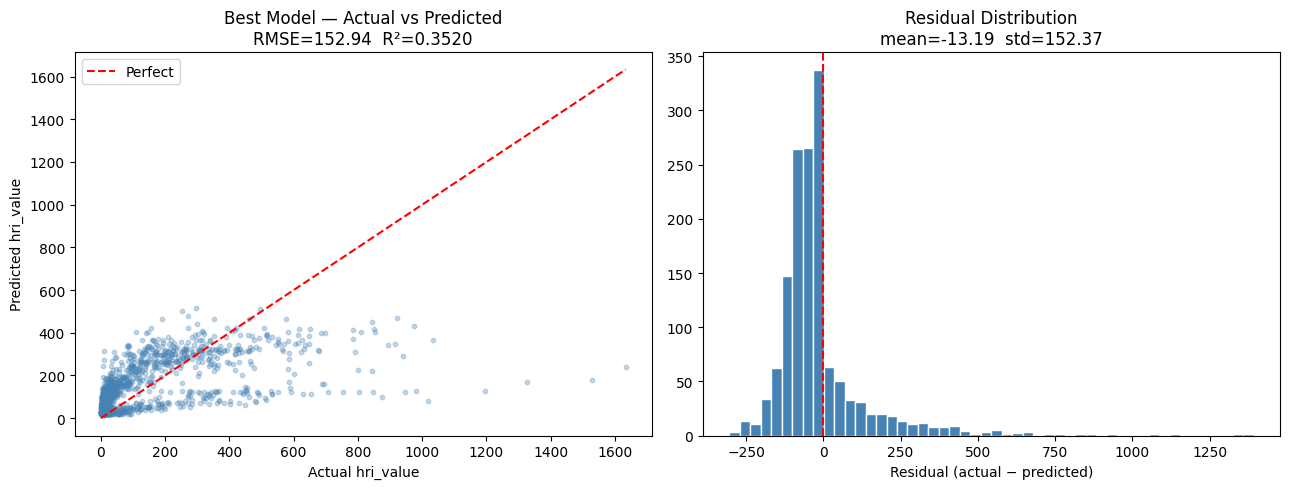

In [37]:
# Identify which model is best and get its predictions
if log_df.loc[log_df['RMSE'].idxmin(), 'experiment'].startswith('E5'):
    best_model  = e5_model
    best_feats  = list(BEST_FEATURES_E5)
    best_preds  = e5_preds
    best_rmse_v = e5_rmse
    best_r2_v   = e5_r2
    X_best_test = df_test_eng[best_feats]
elif log_df.loc[log_df['RMSE'].idxmin(), 'experiment'].startswith('E2'):
    best_model  = e2_model
    best_feats  = ORIGINAL_FEATURES
    best_preds  = np.clip(e2_model.predict(X_test_8), 0, None)
    best_rmse_v = e2_rmse
    best_r2_v   = e2_r2
    X_best_test = X_test_8
else:
    best_model  = e4_model
    best_feats  = ENGINEERED_FEATURES
    best_preds  = np.clip(e4_model.predict(X_test_12), 0, None)
    best_rmse_v = e4_rmse
    best_r2_v   = e4_r2
    X_best_test = X_test_12

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, best_preds, alpha=0.3, s=10, color='steelblue')
lim = max(y_test.max(), best_preds.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('Actual hri_value'); axes[0].set_ylabel('Predicted hri_value')
axes[0].set_title(f'Best Model — Actual vs Predicted\nRMSE={best_rmse_v:.2f}  R²={best_r2_v:.4f}')
axes[0].legend()

residuals = y_test.values - best_preds
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (actual − predicted)')
axes[1].set_title(f'Residual Distribution\nmean={residuals.mean():.2f}  std={residuals.std():.2f}')

plt.tight_layout()
plt.savefig('plot_best_model_diagnostics.png', dpi=150, bbox_inches='tight'); plt.show()

## 11. Final Summary

In [38]:
best_row = log_df.loc[log_df['RMSE'].idxmin()]
print('=' * 65)
print('MEMBER 3 — XGBoost Final Report (Objective-Constrained)')
print('=' * 65)
print(f'Recommended experiment : {best_row["experiment"]}')
print(f'Features used          : {len(best_feats)} → {best_feats}')
print(f'Hyperparameters        : {e4_best_params}')
print()
print('Real Test Metrics (report these to Shah):')
print(f'  real_test_MAE  : {best_row["MAE"]}')
print(f'  real_test_RMSE : {best_row["RMSE"]}')
print(f'  real_test_R2   : {best_row["R2"]}')
print()
print('Experiment progression (valid only):')
for _, row in log_df.iterrows():
    marker = ' ← RECOMMENDED' if row['recommended'] else ''
    print(f'  {row["experiment"]:<38} RMSE={row["RMSE"]}{marker}')
print()
print('Note: Temperature-only model (RMSE≈148) was tested but')
print('disqualified — drops socioeconomic features, cannot')
print('answer the project research question.')
print('=' * 65)

MEMBER 3 — XGBoost Final Report (Objective-Constrained)
Recommended experiment : E5 Feature Selection (valid)
Features used          : 6 → ['max_temp_celsius', 'min_temp_celsius', 'feat_heat_intensity', 'feat_temp_range', 'feat_unsheltered_ratio', 'overall_homeless']
Hyperparameters        : {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 0.8}

Real Test Metrics (report these to Shah):
  real_test_MAE  : 96.4823
  real_test_RMSE : 152.9357
  real_test_R2   : 0.352

Experiment progression (valid only):
  E1 Baseline (8 features)               RMSE=186.3119
  E2 Tuned (8 features)                  RMSE=154.4994
  E3 Baseline (12 features)              RMSE=185.5714
  E4 Tuned (12 features)                 RMSE=155.1588
  E5 Feature Selection (valid)           RMSE=152.9357 ← RECOMMENDED

Note: Temperature-only model (RMSE≈148) was tested but
disqualified — drops socioeconomic features, cannot
answer the project research question.


# 3. Linear Regression ~ Mary Tekele


To ensure any overriden variables are corrected



In [39]:
# Load training dataset (synthetic data)
train_df = pd.read_csv('synthetic_hri_dataset_fixed.csv')

# Load testing dataset (real-world dataset)
test_df = pd.read_csv('final_hri_modeling_dataset.csv')

In [40]:
# Define feature variables (predictors)
features = [
    "max_temp_celsius",
    "min_temp_celsius",
    "feat_poverty_rate",
    "feat_unemployment_rate",
    "feat_median_hh_income",
    "feat_total_population",
    "overall_homeless",
    "unsheltered_homeless"
]

In [41]:
# Split into X (features) and y (target)

# Training data
X_train = train_df[features]
y_train = train_df[target]

# Testing data
X_test = test_df[features]
y_test = test_df[target]

In [42]:
# Define target variable (what we are predicting)
target = "hri_value"

Fitting the Regression Model

In [43]:
# Initialize Linear Regression model
lr = LinearRegression()

In [44]:
# Train the model on synthetic data
lr.fit(X_train, y_train)

LinearRegression()

In [45]:
# Make predictions on real test data
y_pred_lr = lr.predict(X_test)

In [46]:
# Calculate performance metrics

mae_lr = mean_absolute_error(y_test, y_pred_lr)   # average error
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))  # penalizes large errors
r2_lr = r2_score(y_test, y_pred_lr)  # variance explained

print("Linear Regression Performance:")
print("MAE:", round(mae_lr, 3))
print("RMSE:", round(rmse_lr, 3))
print("R²:", round(r2_lr, 3))

Linear Regression Performance:
MAE: 124.815
RMSE: 174.909
R²: 0.152


In [47]:
# Extract coefficients
coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": lr.coef_
}).sort_values(by="coefficient", ascending=False)

coefficients

,feature,coefficient
3,feat_unemployment_rate,25352.486259
0,max_temp_celsius,7.665275
1,min_temp_celsius,4.072611
7,unsheltered_homeless,0.001029
5,feat_total_population,-0.000119
4,feat_median_hh_income,-0.000370
6,overall_homeless,-0.000793
2,feat_poverty_rate,-933.259691


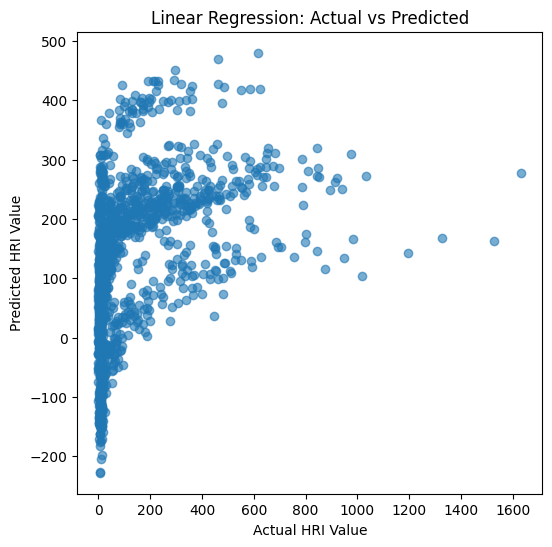

In [48]:
# Visualize Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.xlabel("Actual HRI Value")
plt.ylabel("Predicted HRI Value")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

### Linear Regression Model Assumption Check

We then checked to see if the assumptions for Linear Regression were valid. Overall, we find that not all assummptions hold. However, despite these violations, the model demonstrates strong predictive performance, and linear regression is known to be robust to moderate assumption violations in predictive settings. The model is appropriate for prediciton, but these limitations should still be kept in mind.

In [49]:
# ------------------------------------------------------------
# Summary table for assumptions
# ------------------------------------------------------------

assumption_summary = pd.DataFrame({
    "Assumption": [
        "Linearity",
        "Homoscedasticity",
        "Normality of residuals",
        "Independence of errors",
        "Multicollinearity"
    ],
    "How Checked": [
        "Residuals vs Predicted Plot",
        "Breusch-Pagan Test",
        "Histogram, Q-Q Plot, Shapiro-Wilk Test",
        "Durbin-Watson Statistic",
        "Variance Inflation Factor (VIF)"
    ],
    "Rule of Thumb": [
        "Random scatter around 0",
        "p-value > 0.05",
        "Bell-shaped residuals / Q-Q line / p-value > 0.05",
        "Statistic close to 2",
        "VIF < 5 preferred"
    ]
})

assumption_summary

,Assumption,How Checked,Rule of Thumb
0,Linearity,Residuals vs Predicted Plot,Random scatter around 0
1,Homoscedasticity,Breusch-Pagan Test,p-value > 0.05
2,Normality of residuals,"Histogram, Q-Q Plot, Shapiro-Wilk Test",Bell-shaped residuals / Q-Q line / p-value > 0.05
3,Independence of errors,Durbin-Watson Statistic,Statistic close to 2
4,Multicollinearity,Variance Inflation Factor (VIF),VIF < 5 preferred


**1.) Linearity**

We see a very wide spread of residuals, more scattered outliers, a strong visible pattern/curvature, and poor random scatter around 0, showing violation of linearity.

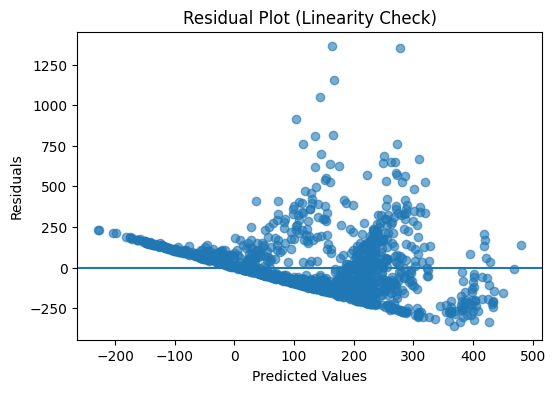

In [50]:
# Residual Plot (errors)
residuals = y_test - y_pred_lr

plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, residuals, alpha=0.6)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linearity Check)")
plt.show()

**2.) Indpependence of Errors**

**Assumption**: 2 ~> No Autocorrelation, which is what we DO want

**Interpretation**: 0.5 ~> Positive Autocorrelation, which is NOT what we want

In [51]:
dw = durbin_watson(residuals)
print("Durbin-Watson:", dw)

Durbin-Watson: 0.5615579032947066


**3.) Homoscedasticity** (constant variance)

**Assumption**: Even spread of Residual Plot & p-value > 0.05

**Interpretation**: p-value is extremely smaller than 0.05, showing strong evidence that the assumption of homoscedasticity is violated.

In [52]:
X_with_const = sm.add_constant(X_test)
bp_test = het_breuschpagan(residuals, X_with_const)

print("Breusch-Pagan p-value:", bp_test[1])

Breusch-Pagan p-value: 4.0474511125526494e-24


**4.) Normality of Residuals**

**Assumption**: We want a rough bell shape / straight line, not a heavey skew.

**Interpretation**: This graph has a very strong right skew, has an uneven bell-shape appearance, is somewhat centered around 0, and the extreme positive residuals are more spread out, showing it poorly holds this assumption

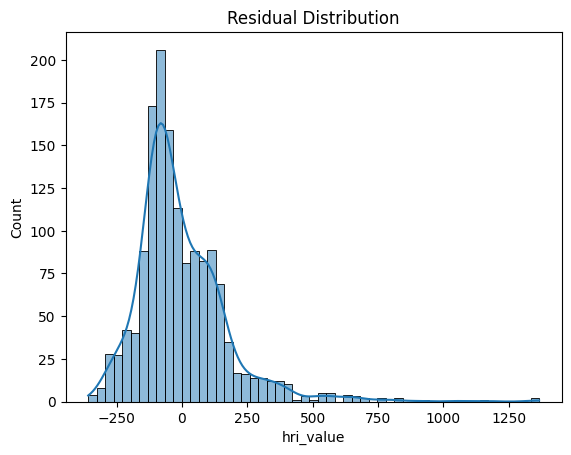

In [53]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

**5. Multicolinearity**

**Assumption**: We want |r| < 0.8

**Interpretation**: Features in the same category (Temperature, Socioeconomic, or Housing) have strong correlation with one another

In [54]:
corr = X_train.corr()
print(corr)

                        max_temp_celsius  min_temp_celsius  feat_poverty_rate  \
max_temp_celsius                1.000000          0.886276          -0.059399   
min_temp_celsius                0.886276          1.000000          -0.035423   
feat_poverty_rate              -0.059399         -0.035423           1.000000   
feat_unemployment_rate         -0.037762         -0.013507           0.929786   
feat_median_hh_income          -0.040583         -0.015500           0.906573   
feat_total_population          -0.015392          0.006504           0.767501   
overall_homeless               -0.011832         -0.022899           0.039744   
unsheltered_homeless           -0.012461         -0.022513           0.031853   

                        feat_unemployment_rate  feat_median_hh_income  \
max_temp_celsius                     -0.037762              -0.040583   
min_temp_celsius                     -0.013507              -0.015500   
feat_poverty_rate                     0.929786     

### Linear Model Feature Selection

Because Linear Regression has no meaningful hyperparameters to tune, we focused instead on improving performance through feature selection.  

Due to the present multicolinearity between features in the same category (Temperature, Demographic, Homelessness), we tested all possible feature combinations to see which combination would produce the best performance metric results. From there, we selected the first group of features where the selected features were not in the same category, due to all the top combinations having very similar performance metric values.



---

Features Selected:
  - **min_temp_celcius**
  - **feat_median_hh_income**
  - **unsheltered_homless**

In [55]:
# Store results from every feature combination
all_results = []

# Loop through every possible feature count:
# 1 feature, 2 features, 3 features, ... all 8 features
for k in range(1, len(features) + 1):

    # Generate every possible combination of k features
    for feature_combo in combinations(features, k):

        # Convert tuple to list so pandas can use it
        feature_combo = list(feature_combo)

        # Create training X using only this feature combination
        X_train_combo = train_df[feature_combo]

        # Create testing X using the same feature combination
        X_test_combo = test_df[feature_combo]

        # Target stays the same
        y_train = train_df[target]
        y_test = test_df[target]

        # Initialize Linear Regression model
        model = LinearRegression()

        # Train on synthetic data
        model.fit(X_train_combo, y_train)

        # Predict on real data
        y_pred_combo = model.predict(X_test_combo)

        # Calculate evaluation metrics
        mae = mean_absolute_error(y_test, y_pred_combo)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred_combo))
        r2 = r2_score(y_test, y_pred_combo)

        # Save the results
        all_results.append({
            "num_features": k,
            "features_used": feature_combo,
            "mae": mae,
            "rmse": rmse,
            "r2": r2
        })

In [56]:
# Convert all results into a dataframe
combo_results = pd.DataFrame(all_results)

# Sort by RMSE because RMSE is your main metric
combo_results_sorted = combo_results.sort_values("rmse").reset_index(drop=True)

# Show best 10 combinations
combo_results_sorted.head(10)

,num_features,features_used,mae,rmse,r2
0,3,"[min_temp_celsius, feat_median_hh_income, feat...",98.011937,148.435691,0.389555
1,2,"[min_temp_celsius, feat_median_hh_income]",98.018568,148.503550,0.388996
2,2,"[min_temp_celsius, feat_total_population]",98.256546,148.873869,0.385945
3,4,"[min_temp_celsius, feat_median_hh_income, feat...",98.948976,149.164207,0.383548
4,3,"[min_temp_celsius, feat_median_hh_income, unsh...",98.964790,149.240569,0.382917
5,1,[min_temp_celsius],98.725101,149.360927,0.381921
6,3,"[min_temp_celsius, feat_total_population, unsh...",99.192508,149.597036,0.379965
7,4,"[min_temp_celsius, feat_median_hh_income, feat...",99.558041,149.631014,0.379683
8,3,"[min_temp_celsius, feat_median_hh_income, over...",99.578232,149.709938,0.379029
9,5,"[min_temp_celsius, feat_median_hh_income, feat...",99.727113,149.751570,0.378684


Improved Linear Model

In [57]:
best_lr_features = ['min_temp_celsius', 'feat_median_hh_income', 'unsheltered_homeless']


In [58]:
# Create training and testing datasets

# Training data (synthetic dataset)
X_train_best_lr = train_df[best_lr_features]
y_train = train_df[target]

# Testing data (real dataset)
X_test_best_lr = test_df[best_lr_features]
y_test = test_df[target]

In [59]:
# Initialize Linear Regression model
lr_best = LinearRegression()

# Train model on synthetic data
lr_best.fit(X_train_best_lr, y_train)

LinearRegression()

In [60]:
# Make predictions on real test data
y_pred_best_lr = lr_best.predict(X_test_best_lr)

In [61]:
# Calculate metrics

mae_best_lr = mean_absolute_error(y_test, y_pred_best_lr)  # average error
rmse_best_lr = np.sqrt(mean_squared_error(y_test, y_pred_best_lr))  # penalizes large errors
r2_best_lr = r2_score(y_test, y_pred_best_lr)  # variance explained

print("Final Linear Regression Performance:")
print("MAE:", round(mae_best_lr, 3))
print("RMSE:", round(rmse_best_lr, 3))
print("R²:", round(r2_best_lr, 3))

Final Linear Regression Performance:
MAE: 98.965
RMSE: 149.241
R²: 0.383


In [62]:
# View model coefficients
coefficients_best_lr = pd.DataFrame({
    "feature": best_lr_features,
    "coefficient": lr_best.coef_
})

coefficients_best_lr

# -> Interpretation:
      #Positive -> Increases HRI
      #Negative -> Decreases HRI

,feature,coefficient
0,min_temp_celsius,10.258566
1,feat_median_hh_income,0.000942
2,unsheltered_homeless,-0.000046


# Model Comparison

We compared the performance metrics of our 3 models in 2 ways:
1. On their baseline performance metrics (no tuning, no feature selection)
2. On their best perfoming improvements (post tuning and feature selection)  


From the model comparisons, we see that the final Linear Regression model had the best RMSE and R^2, but the lowest MAE. Since the primary metric we focused on was RMSE, we decided to move forward with the Linear Regression Model.

In [63]:
# Baseline Comparison
baseline_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "XGBoost"],
    "MAE": [124.815, 105.1342, 115.4181],
    "RMSE": [174.909, 163.6239, 186.3119],
    "R²": [0.152, 0.2582, 0.0383]
})

baseline_comparison = baseline_comparison.sort_values("RMSE").reset_index(drop=True)

baseline_comparison

,Model,MAE,RMSE,R²
0,Decision Tree,105.1342,163.6239,0.2582
1,Linear Regression,124.8150,174.9090,0.1520
2,XGBoost,115.4181,186.3119,0.0383


In [64]:
# Best Tuned Comparison
best_tuned_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "XGBoost"],
    "MAE": [98.965, 91.7907, 96.4823],
    "RMSE": [149.241, 152.9362, 152.9357],
    "R²": [0.383, 0.3520, 0.3520]
})

best_tuned_comparison = best_tuned_comparison.sort_values("RMSE").reset_index(drop=True)

best_tuned_comparison

,Model,MAE,RMSE,R²
0,Linear Regression,98.9650,149.2410,0.383
1,XGBoost,96.4823,152.9357,0.352
2,Decision Tree,91.7907,152.9362,0.352


# Model Selected ~ Linear Regression

## Assumption Check of our best Linear Regression model (the 3 feature model)

**1. Linearity**

We see slight improvement in the linearity assumption. There is slightly tighter spread of residuals, slightly reduced extreme outliers, reduced curvature/pattern, and a slightly improved random scatter around 0.

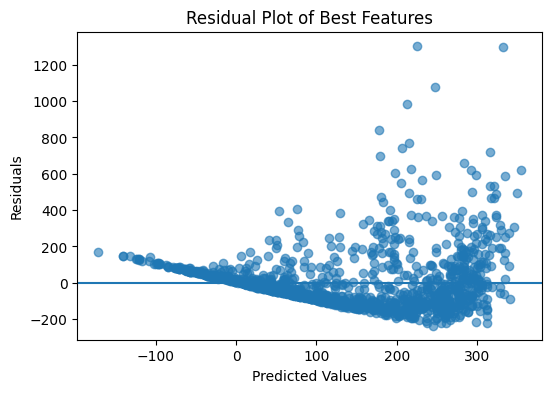

In [65]:
#Residual Plot

# Calculate residuals (errors)
residuals_best_lr = y_test - y_pred_best_lr

plt.figure(figsize=(6,4))
plt.scatter(y_pred_best_lr, residuals_best_lr, alpha=0.6)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot of Best Features")
plt.show()

**2.) Independence of Errors**

Our previous value of 0.56 is now 0.77, which is closer to 2, which means it now has less autocorrelation than the baseline model.

In [66]:
dw_best_lr = durbin_watson(residuals_best_lr)
print("Durbin-Watson:", dw_best_lr)

Durbin-Watson: 0.7672478400008196


**3.) Homoscedasticity** (constant variance)

Our p-value got very slightly worse, showing this feature selection didn't help validate this assumption.

In [67]:
X_with_const_best_lr = sm.add_constant(X_test_best_lr)
bp_test_best_lr = het_breuschpagan(residuals_best_lr, X_with_const_best_lr)

print("Breusch-Pagan p-value:", bp_test_best_lr[1])

Breusch-Pagan p-value: 5.284067209378322e-26


**4.) Normality of Residuals**

Compared to the previous residual plot, this one is centered around 0 more, has a smoother bell-shape appearance, has a reduced right skew, has slightly tighter extreme positive residuals, and has overall improved.

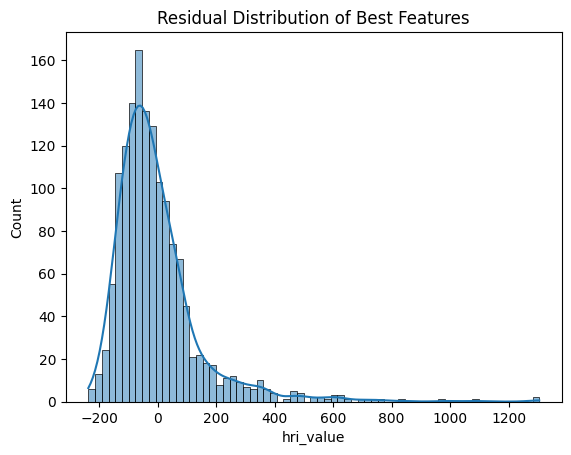

In [68]:
sns.histplot(residuals_best_lr, kde=True)
plt.title("Residual Distribution of Best Features")
plt.show()

**5.) Multicolinearity**

The features now have little correlation to one another.

In [69]:
corr_best_lr = X_train_best_lr.corr()
print(corr_best_lr)

                       min_temp_celsius  feat_median_hh_income  \
min_temp_celsius               1.000000              -0.015500   
feat_median_hh_income         -0.015500               1.000000   
unsheltered_homeless          -0.022513               0.033829   

                       unsheltered_homeless  
min_temp_celsius                  -0.022513  
feat_median_hh_income              0.033829  
unsheltered_homeless               1.000000  


# Further Model Improvements

We decided to go one step further and enhance our final model by applying varying transformations to the final selected features -*min temperature, median household income, and unsheltered homeless count*- to see if we could further improve the invalid model assumptions.

To do this, we attempted the following:
1. **log transformation of HRI**
2. **Adding a minimum temperature squared feature** to capture the nonlinear effects/curvature in the risidual plot and the relationship between temperature and HRI counts.
3. **log transformation of unshelthered homeless count** to reduce the shew/outlier effect in the unsheltered homeless extreme values.
4. **Adding an interaction term betwee temperature and income** becuase low-income populations may be more vulnerable to heat for lack of infastructure, in-home AC units, etc., so this captures potential differences in heat vulnerability across socioeconomic groups.
5. **Incorporating #2,3,4 into the same dataset** to evaluate how a combined model would perform.

## log of HRI

Residual Plot Analysis Shows:
- Still heteroscedasticity
- Still spread increasing
- Slight improvement near low values
- BUT still messy at higher values
Performance Metrics Show:
- MAE improved (73 vs 98.9)
  - Better at average error
- RMSE increased (157.9 vs 149.2)
  - Worse at large errors
- R^2 decreased (0.309 vs 0.383)
   - Explains less variation
        
RMSE matters more than MAE, since accurately predicting extreme heat-related illness levels is critical.

Thus, Log Transformation did NOT fix the core problem.

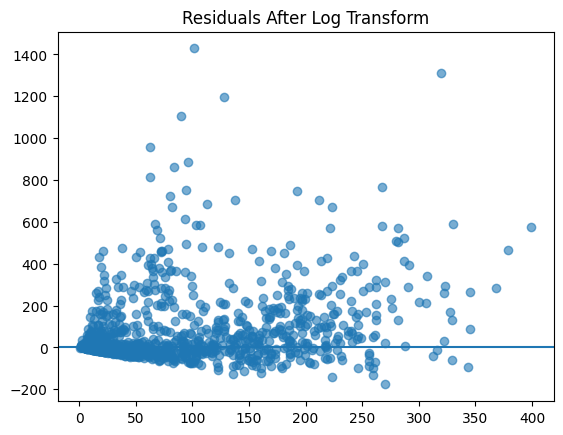

In [70]:
# Transform target
y_train_log = np.log1p(y_train)

# Train model
lr_log = LinearRegression()
lr_log.fit(X_train_best_lr, y_train_log)

# Predict and convert back
y_pred_log = lr_log.predict(X_test_best_lr)
y_pred2 = np.expm1(y_pred_log)

# Residuals
residuals = y_test - y_pred2

# Plot again
plt.scatter(y_pred2, residuals, alpha=0.6)
plt.axhline(0)
plt.title("Residuals After Log Transform")
plt.show()

## Other Transformations

In [71]:
# ------------------------------------------------------------
# 1. Define target and original selected features
# ------------------------------------------------------------

target = "hri_value"

best_features = [
    "min_temp_celsius",
    "feat_median_hh_income",
    "unsheltered_homeless"
]

X_train_best = train_df[best_features]
X_test_best = test_df[best_features]

y_train = train_df[target]
y_test = test_df[target]

In [72]:
# ------------------------------------------------------------
# 2. Helper function to train + evaluate any Linear Regression model
# ------------------------------------------------------------

def evaluate_linear_model(model_name, train_data, test_data, feature_list):
    """
    Trains Linear Regression using selected features,
    predicts on real test data, and returns MAE, RMSE, R².
    """

    X_train_model = train_data[feature_list]
    X_test_model = test_data[feature_list]

    model = LinearRegression()
    model.fit(X_train_model, y_train)

    predictions = model.predict(X_test_model)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    print(f"\n{model_name}")
    print("Features:", feature_list)
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R²:", round(r2, 3))

    return {
        "model": model_name,
        "features": feature_list,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "trained_model": model,
        "predictions": predictions
    }

In [73]:
# ------------------------------------------------------------
# 3. Original 3-feature model
# ------------------------------------------------------------

results = []

original_result = evaluate_linear_model(
    model_name="Original 3-Feature Linear Model",
    train_data=train_df,
    test_data=test_df,
    feature_list=best_features
)

results.append(original_result)


Original 3-Feature Linear Model
Features: ['min_temp_celsius', 'feat_median_hh_income', 'unsheltered_homeless']
MAE: 98.965
RMSE: 149.241
R²: 0.383


In [74]:
# ------------------------------------------------------------
# 4. Polynomial temperature model
# Adds min_temp_celsius squared to capture curvature
# ------------------------------------------------------------

train_df["min_temp_sq"] = train_df["min_temp_celsius"] ** 2
test_df["min_temp_sq"] = test_df["min_temp_celsius"] ** 2

poly_features = [
    "min_temp_celsius",
    "min_temp_sq",
    "feat_median_hh_income",
    "unsheltered_homeless"
]

poly_result = evaluate_linear_model(
    model_name="Polynomial Temp Model",
    train_data=train_df,
    test_data=test_df,
    feature_list=poly_features
)

results.append(poly_result)


Polynomial Temp Model
Features: ['min_temp_celsius', 'min_temp_sq', 'feat_median_hh_income', 'unsheltered_homeless']
MAE: 86.276
RMSE: 141.728
R²: 0.443


In [75]:
# ------------------------------------------------------------
# 5. Log-transform unsheltered homelessness
# Reduces skew/outlier effect in homelessness variable
# ------------------------------------------------------------

train_df["log_unsheltered_homeless"] = np.log1p(train_df["unsheltered_homeless"])
test_df["log_unsheltered_homeless"] = np.log1p(test_df["unsheltered_homeless"])

log_feature_model_features = [
    "min_temp_celsius",
    "feat_median_hh_income",
    "log_unsheltered_homeless"
]

log_feature_result = evaluate_linear_model(
    model_name="Log Unsheltered Feature Model",
    train_data=train_df,
    test_data=test_df,
    feature_list=log_feature_model_features
)

results.append(log_feature_result)


Log Unsheltered Feature Model
Features: ['min_temp_celsius', 'feat_median_hh_income', 'log_unsheltered_homeless']
MAE: 99.478
RMSE: 149.629
R²: 0.38


In [76]:
# ------------------------------------------------------------
# 6. Interaction term: temperature × income
# Tests whether temperature effect changes by income level
# ------------------------------------------------------------

train_df["temp_income_interaction"] = (
    train_df["min_temp_celsius"] * train_df["feat_median_hh_income"]
)

test_df["temp_income_interaction"] = (
    test_df["min_temp_celsius"] * test_df["feat_median_hh_income"]
)

interaction_features = [
    "min_temp_celsius",
    "feat_median_hh_income",
    "unsheltered_homeless",
    "temp_income_interaction"
]

interaction_result = evaluate_linear_model(
    model_name="Temperature × Income Interaction Model",
    train_data=train_df,
    test_data=test_df,
    feature_list=interaction_features
)

results.append(interaction_result)


Temperature × Income Interaction Model
Features: ['min_temp_celsius', 'feat_median_hh_income', 'unsheltered_homeless', 'temp_income_interaction']
MAE: 98.717
RMSE: 148.842
R²: 0.386


In [77]:
# ------------------------------------------------------------
# 7. Combined engineered model
# Includes polynomial temp, log homelessness, and interaction
# ------------------------------------------------------------

combined_features = [
    "min_temp_celsius",
    "min_temp_sq",
    "feat_median_hh_income",
    "log_unsheltered_homeless",
    "temp_income_interaction"
]

combined_result = evaluate_linear_model(
    model_name="Combined Engineered Linear Model",
    train_data=train_df,
    test_data=test_df,
    feature_list=combined_features
)

results.append(combined_result)


Combined Engineered Linear Model
Features: ['min_temp_celsius', 'min_temp_sq', 'feat_median_hh_income', 'log_unsheltered_homeless', 'temp_income_interaction']
MAE: 86.209
RMSE: 141.393
R²: 0.446


In [78]:
# ------------------------------------------------------------
# 8. Compare all transformation results
# ------------------------------------------------------------

comparison_df = pd.DataFrame([
    {
        "model": r["model"],
        "num_features": len(r["features"]),
        "features": r["features"],
        "mae": r["mae"],
        "rmse": r["rmse"],
        "r2": r["r2"]
    }
    for r in results
])

comparison_df = comparison_df.sort_values("rmse").reset_index(drop=True)

comparison_df

,model,num_features,features,mae,rmse,r2
0,Combined Engineered Linear Model,5,"[min_temp_celsius, min_temp_sq, feat_median_hh...",86.209439,141.393450,0.446103
1,Polynomial Temp Model,4,"[min_temp_celsius, min_temp_sq, feat_median_hh...",86.275848,141.728151,0.443478
2,Temperature × Income Interaction Model,4,"[min_temp_celsius, feat_median_hh_income, unsh...",98.716726,148.842212,0.386206
3,Original 3-Feature Linear Model,3,"[min_temp_celsius, feat_median_hh_income, unsh...",98.964790,149.240569,0.382917
4,Log Unsheltered Feature Model,3,"[min_temp_celsius, feat_median_hh_income, log_...",99.478118,149.628901,0.379701


**Interpretation**: The engineered linear model achieved the best performance, reducing RMSE from approximately 149 to 141. This improvement was primarily driven by the inclusion of a polynomial temperature term, indicating a nonlinear relationship between temperature and heat-related illness. Other transformations, such as interaction and log transformations, did not improve performance that much as seen by their performance metrics, suggesting that nonlinearity in temperature is the dominant factor.

In [79]:
# ------------------------------------------------------------
# 9. Select best model based on RMSE
# ------------------------------------------------------------

best_result = min(results, key=lambda x: x["rmse"])

best_model_name = best_result["model"]
best_model = best_result["trained_model"]
best_predictions = best_result["predictions"]
best_features_final = best_result["features"]

print("Best Model Based on RMSE:")
print(best_model_name)
print("Features:", best_features_final)
print("RMSE:", round(best_result["rmse"], 3))
print("MAE:", round(best_result["mae"], 3))
print("R²:", round(best_result["r2"], 3))

Best Model Based on RMSE:
Combined Engineered Linear Model
Features: ['min_temp_celsius', 'min_temp_sq', 'feat_median_hh_income', 'log_unsheltered_homeless', 'temp_income_interaction']
RMSE: 141.393
MAE: 86.209
R²: 0.446


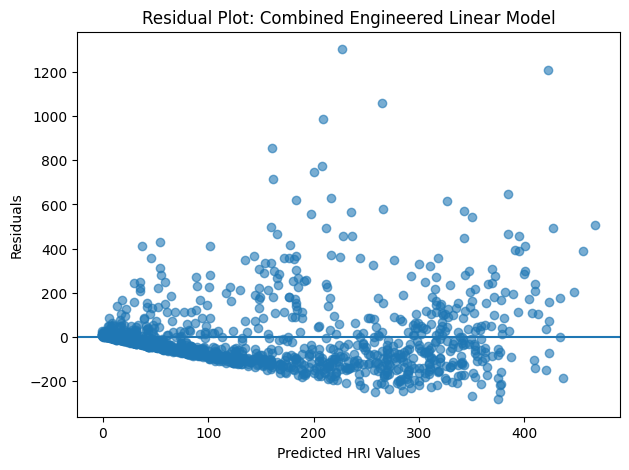

In [80]:
# ------------------------------------------------------------
# 10. Plot residuals for best model
# ------------------------------------------------------------

best_residuals = y_test - best_predictions

plt.figure(figsize=(7,5))
plt.scatter(best_predictions, best_residuals, alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted HRI Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot: {best_model_name}")
plt.show()

# Final Assumption Check of Transformed Model

Based on these results, we don't see too much improvement in the validation of the model assumptions, however, despite these assumption violations, the model still achieved strong predictive performance and improved RMSE after feature engineering and transformatioons, suggesting that the model remains useful for prediction even though it is not a perfectly specified classical linear regression model.

In [81]:
# ------------------------------------------------------------
# 1. Define best model features
# ------------------------------------------------------------

best_features_final = [
    "min_temp_celsius",
    "min_temp_sq",
    "feat_median_hh_income",
    "log_unsheltered_homeless",
    "temp_income_interaction"
]

target = "hri_value"

X_train_best = train_df[best_features_final]
X_test_best = test_df[best_features_final]

y_train = train_df[target]
y_test = test_df[target]

In [82]:
# ------------------------------------------------------------
# 2. Fit best linear model
# ------------------------------------------------------------

from sklearn.linear_model import LinearRegression

best_lr = LinearRegression()
best_lr.fit(X_train_best, y_train)

y_pred = best_lr.predict(X_test_best)
residuals = y_test - y_pred

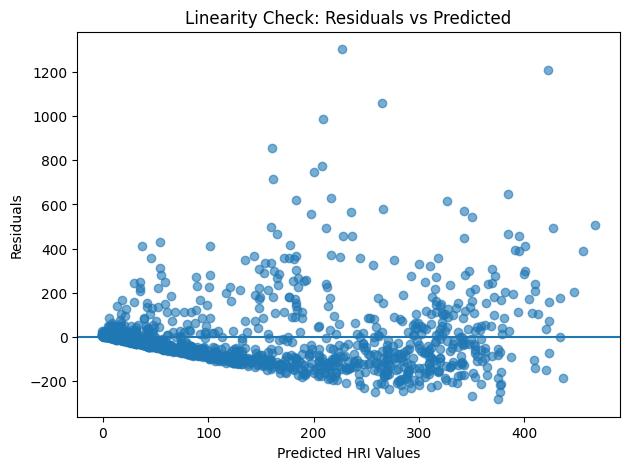

In [83]:
# ------------------------------------------------------------
# 3. Assumption 1: Linearity
# Residuals should be randomly scattered around 0
# ------------------------------------------------------------

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted HRI Values")
plt.ylabel("Residuals")
plt.title("Linearity Check: Residuals vs Predicted")
plt.show()

In [84]:
# ------------------------------------------------------------
# 4. Assumption 2: Homoscedasticity
# Breusch-Pagan test checks whether residual variance is constant.
# p-value > 0.05 = no strong evidence of heteroscedasticity.
# p-value <= 0.05 = heteroscedasticity likely exists.
# ------------------------------------------------------------

X_test_const = sm.add_constant(X_test_best)

bp_test = het_breuschpagan(residuals, X_test_const)

bp_results = {
    "LM Statistic": bp_test[0],
    "LM p-value": bp_test[1],
    "F Statistic": bp_test[2],
    "F p-value": bp_test[3]
}

bp_results

{'LM Statistic': np.float64(118.43594525085867),
 'LM p-value': np.float64(6.729130058658378e-24),
 'F Statistic': np.float64(25.672402862187482),
 'F p-value': np.float64(6.800611058562838e-25)}

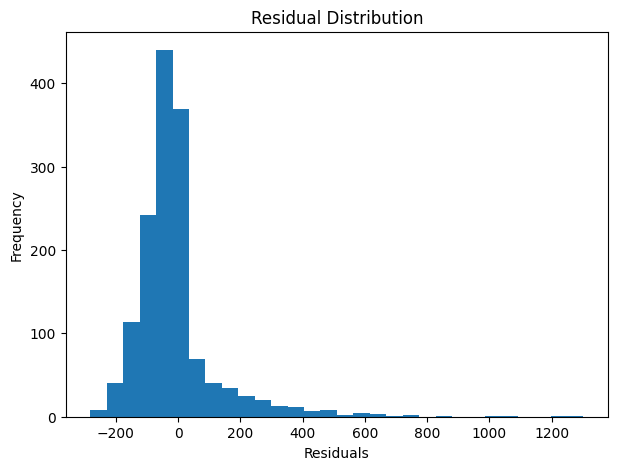

In [85]:
# ------------------------------------------------------------
# 5. Assumption 3: Normality of residuals
# Histogram should look roughly bell-shaped.
# Q-Q plot points should roughly follow the diagonal line.
# ------------------------------------------------------------

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

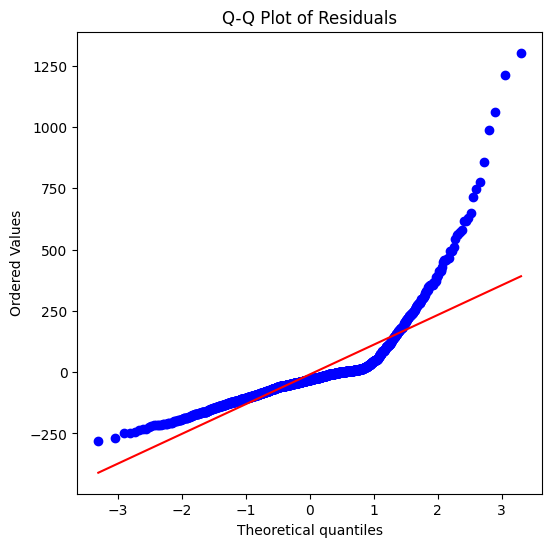

In [86]:
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [87]:
# Optional formal normality test
# p-value > 0.05 suggests residuals are approximately normal
# p-value <= 0.05 suggests residuals are not normally distributed

shapiro_stat, shapiro_p = stats.shapiro(residuals.sample(500, random_state=42) if len(residuals) > 500 else residuals)

print("Shapiro-Wilk Test")
print("Statistic:", round(shapiro_stat, 4))
print("p-value:", round(shapiro_p, 4))

Shapiro-Wilk Test
Statistic: 0.7489
p-value: 0.0


In [88]:
# ------------------------------------------------------------
# 6. Assumption 4: Independence of errors
# Durbin-Watson checks autocorrelation in residuals.
# Around 2 = good
# < 1.5 = positive autocorrelation
# > 2.5 = negative autocorrelation
# ------------------------------------------------------------

dw_stat = durbin_watson(residuals)

print("Durbin-Watson Statistic:", round(dw_stat, 4))

Durbin-Watson Statistic: 0.7549


In [89]:
# ------------------------------------------------------------
# 7. Assumption 5: Multicollinearity
# VIF checks whether features are highly redundant.
# VIF < 5 = acceptable
# VIF 5-10 = moderate concern
# VIF > 10 = serious multicollinearity
# ------------------------------------------------------------

X_vif = sm.add_constant(X_train_best)

vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df

,feature,VIF
0,const,143.082347
1,min_temp_celsius,93.256512
2,min_temp_sq,1.203382
3,feat_median_hh_income,1.083494
4,log_unsheltered_homeless,1.005464
5,temp_income_interaction,92.580302


# SHAP Analysis


In [90]:
# Preparing the data using the same features the model was trained on
best_features_final = [
    "min_temp_celsius",
    "min_temp_sq",
    "feat_median_hh_income",
    "log_unsheltered_homeless",
    "temp_income_interaction"
]

X_train_best = train_df[best_features_final]
X_test_best = test_df[best_features_final]

In [91]:
# Create SHAP explainer
explainer = shap.LinearExplainer(best_model, X_train_best)

In [92]:
# Compute SHAP values
shap_values = explainer.shap_values(X_test_best)

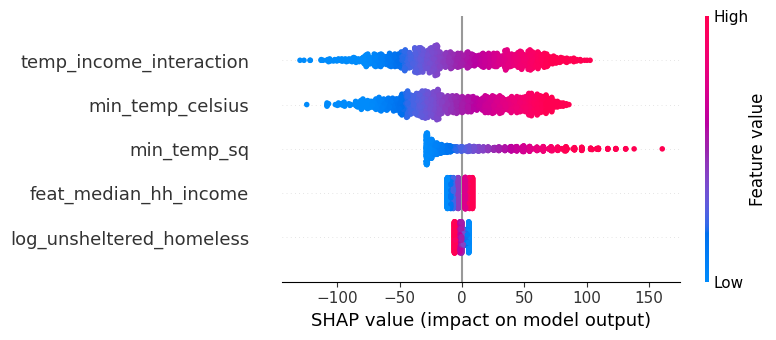

In [93]:
# Summary Plot
shap.summary_plot(shap_values, X_test_best)

**Interpretation** from most to least important features:

1. **temp_income_interaction**: This suggests that the relationship between temperature and HRI changes slightly depending on income levels. However, because this feature is mathematically tied to temperature, it primarily reinforces the overall temperature effect rather than acting as an independent driver.
2. **min_temp_celcius**: Temperature is one of the strongest predictors of heat-related illness. As minimum temperatures rise, the model predicts significantly higher HRI counts.
3. **min_temp_sq**: This confirms a nonlinear relationship between temperature and HRI. Heat-related illness does not increase at a constant rate — instead, risk accelerates as temperatures become more extreme. This validates why adding the polynomial temperature term improved model performance.
4. **feat_median_hh_income**: Median household income contributes some predictive information, but its impact is much smaller than temperature-related variables. It likely captures differences in vulnerability or access to resources across regions.
5. **log_unsheltered_homeless**: Unsheltered homelessness has a relatively minor effect on predictions compared to weather variables, though it still provides some additional contextual information about vulnerable populations.


**Overall**:
- Temperature is the strongest driver of HRI predicitions, especially at extreme temperatures where illness risk increases nonlinearly.
- Socioeconomic factors contribute additional context but have smaller overall impact.